# Analyse des résultats — Pipeline T1

Ce notebook compare les solveurs exacts et l'heuristique sur les résultats
du pipeline T1.

## Questions centrales
1. **Quel solveur est meilleur ?** MaxOneModel vs MaxSurfaceModel — sur la même
   instance, qui trouve plus de 1s, une surface plus grande, une meilleure densité ?
2. **Compromis vitesse / qualité** — l'heuristique est-elle assez proche de
   l'optimal pour justifier son gain de temps ?
3. **Accélération** — sur quelles instances le solveur exact est-il lent ?

## Colonnes clés
| Colonne | Description |
|---------|-------------|
| `instance_id` | Identifiant de l'instance |
| `m`, `n` | Dimensions de la matrice d'entrée |
| `base_dens` | Densité globale de la matrice d'entrée |
| `gamma` | Contrainte de densité minimale sur la sous-matrice sélectionnée |
| `solver` | Solveur utilisé (`MaxOneModel` / `MaxSurfaceModel`) |
| `heuristic` | `NaN`/`exact` = solveur exact (optimal garanti) ; `heuristicA` = heuristique standalone |
| `time` | Temps de calcul (secondes) |
| `status` | `optimal` / `time_limit` (solution valide + gap résiduel) / `error` |
| `objective` | Nombre de 1s dans la sous-matrice sélectionnée |
| `area` | Taille de la sous-matrice sélectionnée (lignes × colonnes) |
| `density` | `objective / area` |
| `gap` | Écart (%) entre heuristique et exact — uniquement sur les lignes heuristiques |

In [14]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys, json, warnings, textwrap
from itertools import combinations
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Conteneur pour l'export PDF
_pdf_figs = []                # Figures globales (S1, overlay, etc.)
_pdf_figs_gamma = {}          # {gamma_val: [(fig, title), ...]}

print(f"pandas {pd.__version__} / numpy {np.__version__} / seaborn {sns.__version__}")

pandas 3.0.1 / numpy 2.4.3 / seaborn 0.13.2


## Configuration

- `CSV_SOURCE` : dossier contenant les `*.csv` **ou** liste de chemins de fichiers
- `JSON_LOG_PATH` / `MATRIX_DIR` : overlay solution (mettre `None` pour désactiver)
- `PDF_OUTPUT` : chemin du rapport PDF généré

In [15]:
# ── Option A : dossier (charge tous les *.csv)
CSV_SOURCE = Path("../results")

# ── Option B : liste explicite (décommenter)
# CSV_SOURCE = [
#     Path("../T1/results/results_1773401865.csv"),
#     Path("../T1/results/results_1773403967.csv"),
# ]

# ── Overlay solution ──────────────────────────────────────────────────────────
JSON_LOG_PATH = None   # ex. Path("../T1/results/logs/MonInstance__...json")
MATRIX_DIR    = None   # ex. Path("../data")

# ── Analyse des scales ────────────────────────────────────────────────────────
LOG_THRESHOLD_DECADES = 1   # Seuil pour recommander l'échelle log (ordres de grandeur)

# ── Export PDF ────────────────────────────────────────────────────────────────
PDF_OUTPUT = Path("rapport_analyse.pdf")

# ── Valeurs de gamma ────────────────────────────────────────────────────────────────
GAMMA_VALUES = None  # Auto: toutes les valeurs de gamma; ou liste ex. [1.0, 0.8]

# ── Comparaison solveurs ───────────────────────────────────────────────────────
SOLVER_PAIRS = None  # Auto: toutes les paires
# SOLVER_PAIRS = [("MaxOneModel", "MaxSurfaceModel")]  # Manual: liste spécifique

## Chargement, nettoyage et préparation des données

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Chargement
# ─────────────────────────────────────────────────────────────────────────────
def load_results(source) -> pd.DataFrame:
    """
    Charge un ou plusieurs CSV de résultats.

    Parameters
    ----------
    source : Path | str | list[Path | str]
        Dossier (→ tous les *.csv) ou fichier unique ou liste de fichiers.

    Returns
    -------
    pd.DataFrame avec colonne `source_file` (nom du fichier sans chemin).
    """
    if isinstance(source, (str, Path)):
        p = Path(source)
        files = sorted(p.glob("*.csv")) if p.is_dir() else [p]
    else:
        files = [Path(f) for f in source]

    if not files:
        raise FileNotFoundError(f"Aucun CSV trouvé dans : {source}")

    frames = []
    for f in files:
        try:
            tmp = pd.read_csv(f)
            tmp["source_file"] = f.name
            frames.append(tmp)
            print(f"  ✓  {f.name:<50}  {len(tmp):>4} lignes")
        except Exception as e:
            print(f"  ✗  {f.name}  ERREUR : {e}")

    if not frames:
        raise ValueError("Aucun CSV chargé.")

    df = pd.concat(frames, ignore_index=True)
    print(f"\nTotal brut : {len(df)} lignes  — {df['source_file'].nunique()} fichier(s)")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Nettoyage
# ─────────────────────────────────────────────────────────────────────────────
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Nettoyage et enrichissement :
    - Coercion numérique
    - Normalisation heuristic : NaN / 'NA' → 'exact'
    - Colonnes dérivées : `size`, `is_heuristic`
    """
    df = df.copy()

    for c in ["m","n","base_dens","gamma","time","objective","area","density","gap"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "heuristic" in df.columns:
        df["heuristic"] = df["heuristic"].fillna("exact").replace("NA", "exact")

    df["size"] = df["m"] * df["n"]
    df["is_heuristic"] = df["heuristic"] != "exact"

    return df


# ─────────────────────────────────────────────────────────────────────────────
# Sous-DataFrames de travail
# ─────────────────────────────────────────────────────────────────────────────
def build_subsets(df: pd.DataFrame):
    """
    Retourne (df_exact, df_heur, df_paired, df_solver_cmp).

    df_exact      : runs avec solveur exact (optimal garanti)
    df_heur       : runs heuristiques (moyennés sur les seeds)
    df_paired     : jointure exact+heuristique sur (instance_id, solver)
                    → speedup, obj_ratio
    df_solver_cmp : pivot exact par solver — pour comparer MaxOneModel vs MaxSurfaceModel
    """
    df_exact = df[~df["is_heuristic"]].copy()
    df_heur  = df[df["is_heuristic"]].copy()

    # Agréger heuristique sur les seeds (moyenne)
    agg_cols = {c: "mean" for c in ["time","objective","area","density","gap"] if c in df_heur.columns}
    agg_cols["seed"] = "count"
    df_heur_agg = (
        df_heur
        .groupby(["instance_id","solver","heuristic"], as_index=False)
        .agg(agg_cols)
        .rename(columns={"seed": "n_seeds"})
    )

    # Jointure exact + heuristique
    left_cols  = [c for c in ["instance_id","solver","time","objective","area","density","status","size"]
                  if c in df_exact.columns]
    right_cols = [c for c in ["instance_id","solver","heuristic","time","objective","area","density","gap","n_seeds"]
                  if c in df_heur_agg.columns]

    df_paired = pd.merge(
        df_exact[left_cols].rename(columns={
            "time":"time_exact","objective":"obj_exact",
            "area":"area_exact","density":"dens_exact"}),
        df_heur_agg[right_cols].rename(columns={
            "time":"time_heur","objective":"obj_heur",
            "area":"area_heur","density":"dens_heur"}),
        on=["instance_id","solver"],
        how="inner",
    )
    df_paired["speedup"]   = df_paired["time_exact"] / df_paired["time_heur"].clip(lower=1e-9)
    df_paired["obj_ratio"] = df_paired["obj_heur"] / df_paired["obj_exact"].replace(0, np.nan)

    # Pivot solveurs — comparaison exacte MaxOneModel vs MaxSurfaceModel
    df_solver_cmp = None
    if df_exact["solver"].nunique() >= 2:
        df_solver_cmp = df_exact.pivot_table(
            index="instance_id", columns="solver",
            values=["objective","area","density","time"],
            aggfunc="mean",
        )

    return df_exact, df_heur, df_paired, df_solver_cmp


# ─────────────────────────────────────────────────────────────────────────────
# Recommandation d'échelle automatique
# ─────────────────────────────────────────────────────────────────────────────
def recommend_scale(series, threshold_decades: float = None) -> str:
    """
    Recommande 'log' ou 'linear' selon la distribution d'une série.

    Critère log : la plage (avec offset) couvre ≥ LOG_THRESHOLD_DECADES ordres de grandeur.
    Les zéros/négatifs sont traités avec un petit offset (1e-10).
    """
    if threshold_decades is None:
        threshold_decades = LOG_THRESHOLD_DECADES
    s = series.dropna()
    if len(s) < 2:
        return "linear"
    # Appliquer un petit offset pour gérer les zéros
    s_shifted = np.abs(s) + 1e-10
    decades = np.log10(s_shifted.max() / s_shifted.min())
    return "log" if decades >= threshold_decades else "linear"

# ── Exécution ─────────────────────────────────────────────────────────────────
df_raw  = load_results(CSV_SOURCE)
df      = clean_data(df_raw)
df_exact, df_heur, df_paired, df_solver_cmp = build_subsets(df)

print(f"\n  Runs exacts      : {len(df_exact)}")
print(f"  Runs heuristiques: {len(df_heur)}")
print(f"  Paires appariées : {len(df_paired)}")
if df_solver_cmp is not None:
    print(f"  Solveurs uniques : {df['solver'].unique().tolist()}")

# Valeurs de gamma
if GAMMA_VALUES is None:
    gammas = sorted(df["gamma"].dropna().unique().tolist())
else:
    gammas = GAMMA_VALUES
print(f"  Valeurs de gamma : {gammas}")
df.head(3)

  ✓  res_data.csv                                          66 lignes
  ✓  result_txt.csv                                        28 lignes

Total brut : 94 lignes  — 2 fichier(s)

  Runs exacts      : 47
  Runs heuristiques: 47
  Paires appariées : 47
  Solveurs uniques : ['MaxOneModel', 'MaxSurfaceModel', 'MaxERModel']
  Valeurs de gamma : [1.0]


,instance_id,m,n,base_dens,gamma,solver,seed,heuristic,time,status,objective,area,density,gap,source_file,size,is_heuristic
0,data0,3,3,0.666667,1.0,MaxOneModel,1898197403,exact,0.0041,optimal,4,4,1.0,NaN,res_data.csv,9,False
1,data1,10,10,0.360000,1.0,MaxOneModel,1898197403,exact,0.0073,optimal,20,20,1.0,NaN,res_data.csv,100,False
2,data0,3,3,0.666667,1.0,MaxSurfaceModel,1898197403,exact,0.0040,optimal,4,4,1.0,NaN,res_data.csv,9,False


## Résumé statistique

In [17]:
n_inst   = df["instance_id"].nunique()
solvers  = df["solver"].unique().tolist()
statuts  = df["status"].value_counts().to_dict() if "status" in df.columns else {}
has_heur = len(df_heur) > 0

print(f"Instances          : {n_inst}")
print(f"Solveurs           : {solvers}")
print(f"Statuts (tous runs): {statuts}")
print(f"Heuristiques       : {df_heur['heuristic'].unique().tolist() if has_heur else 'aucune'}")
if has_heur and "gap" in df_heur.columns:
    print(f"Gap médian         : {df_heur['gap'].median():.1f} %")
    print(f"Gap max            : {df_heur['gap'].max():.1f} %")
if has_heur and len(df_paired) > 0:
    print(f"Speedup médian     : {df_paired['speedup'].median():.1f}×")
    print(f"Speedup max        : {df_paired['speedup'].max():.1f}×")

Instances          : 18
Solveurs           : ['MaxOneModel', 'MaxSurfaceModel', 'MaxERModel']
Statuts (tous runs): {'optimal': 77, 'time_limit': 10, 'error': 7}
Heuristiques       : ['heuristicA']
Gap médian         : 0.0 %
Gap max            : 100.0 %
Speedup médian     : 2.0×
Speedup max        : 103.0×


---
## 0.5 — Analyse des échelles

Analyse automatique des distributions pour recommander l'échelle adaptée
(linéaire ou logarithmique) sur chaque axe.
Les graphiques suivants utilisent ces recommandations dynamiquement.

In [18]:
# ── Recommandations d'échelle ──────────────────────────────────────────────
_col_defs = [
    ("time",      "Temps de calcul", df),
    ("objective", "Objectif",        df),
    ("area",      "Surface (area)",  df),
    ("density",   "Densité",         df),
    ("gap",       "Gap (%)",         df),
]
if len(df_paired):
    _col_defs += [
        ("speedup",   "Speedup",        df_paired),
        ("obj_ratio", "Ratio objectif", df_paired),
    ]

_scale_rows = []
for col, label, src in _col_defs:
    if col not in src.columns:
        continue
    s = src[col].dropna()
    if len(s) == 0:
        continue
    # Calculer décades avec offset pour gérer les zéros
    s_shifted = np.abs(s) + 1e-10
    dec = f"{np.log10(s_shifted.max() / s_shifted.min()):.1f}"
    rec = recommend_scale(s)
    _scale_rows.append({
        "Colonne":              col,
        "Label":                label,
        "Min":                  f"{s.min():.4g}",
        "Max":                  f"{s.max():.4g}",
        "Médiane":              f"{s.median():.4g}",
        "Décades (log10)":      dec,
        "Asymétrie":            f"{s.skew():.2f}",
        "Échelle recommandée":  rec,
    })

df_scale_analysis = pd.DataFrame(_scale_rows)
print(df_scale_analysis.to_string(index=False))

# Dictionnaire utilisé par les cellules de graphiques
_scale = {row["Colonne"]: row["Échelle recommandée"] for row in _scale_rows}

  Colonne           Label    Min   Max Médiane Décades (log10) Asymétrie Échelle recommandée
     time Temps de calcul 0.0015 602.4     4.3             5.6      1.80                 log
objective        Objectif      0  6400      93            13.8      2.30                 log
     area  Surface (area)      0  6400      93            13.8      2.30                 log
  density         Densité      0     1       1            10.0     -3.29                 log
      gap         Gap (%)      0   100       0            12.0      1.61                 log
  speedup         Speedup 0.1875   103   1.999             2.7      2.84                 log
obj_ratio  Ratio objectif      0     1       1            10.0     -1.61                 log


---
## 1 — Aperçu général

Répartition des statuts et des types de runs (exact vs heuristique) par solveur
et par fichier source.
Un run `time_limit` retourne la meilleure solution trouvée mais avec un gap résiduel.

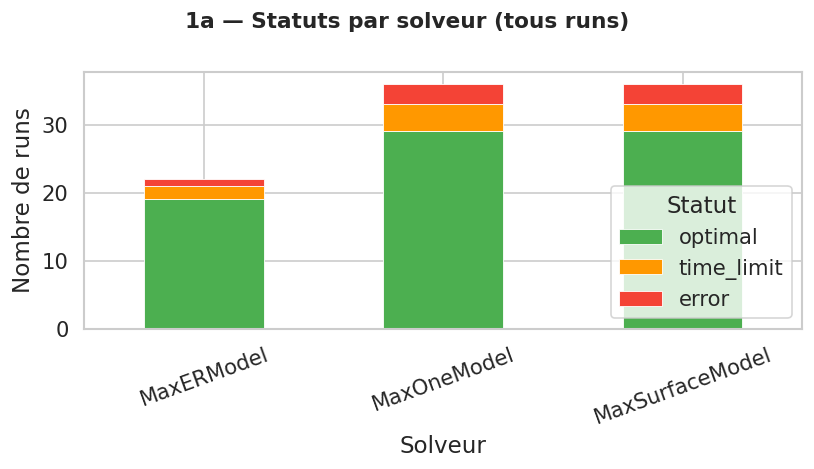

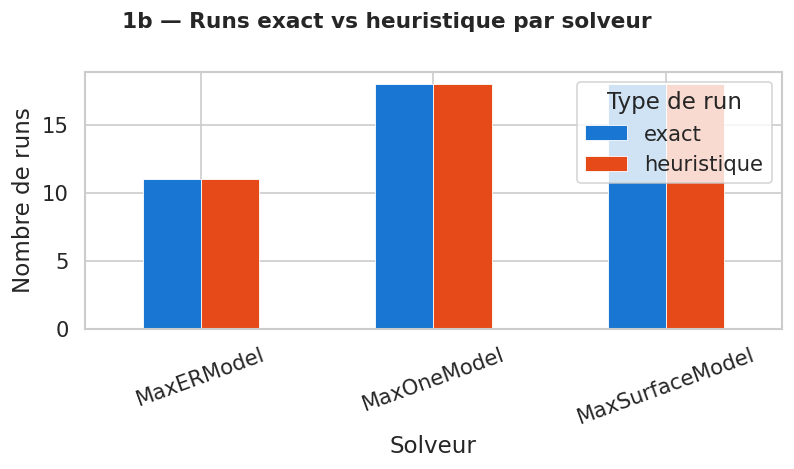

In [19]:
if "status" not in df.columns:
    print("Colonne 'status' absente — section ignorée")
else:
    palette_status = {"optimal":"#4caf50","time_limit":"#ff9800","error":"#f44336"}
    status_order   = [s for s in ["optimal","time_limit","error"] if s in df["status"].unique()]

    # ── Fig 1a : Statuts par solveur ──────────────────────────────────────────
    fig1a, ax = plt.subplots(figsize=(7, 4))
    fig1a.suptitle("1a — Statuts par solveur (tous runs)", fontsize=13, fontweight="bold")
    ct = (df.groupby(["solver","status"]).size()
            .unstack(fill_value=0)
            .reindex(columns=status_order, fill_value=0))
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[palette_status.get(c,"#9e9e9e") for c in ct.columns],
            edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Solveur")
    ax.set_ylabel("Nombre de runs")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Statut")
    plt.tight_layout()
    _pdf_figs.append((fig1a, "1a — Statuts par solveur"))
    plt.show()

    # ── Fig 1b : Exact vs heuristique par solveur ─────────────────────────────
    fig1b, ax = plt.subplots(figsize=(7, 4))
    fig1b.suptitle("1b — Runs exact vs heuristique par solveur", fontsize=13, fontweight="bold")
    type_ct = (df.assign(type=df["is_heuristic"].map({True:"heuristique",False:"exact"}))
               .groupby(["solver","type"]).size()
               .unstack(fill_value=0))
    type_ct.plot(kind="bar", stacked=False, ax=ax,
                 color=["#1976d2","#e64a19"], edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Solveur")
    ax.set_ylabel("Nombre de runs")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Type de run")
    plt.tight_layout()
    _pdf_figs.append((fig1b, "1b — Exact vs heuristique"))
    plt.show()

---
## 2 — Comparaison des solveurs exacts

MaxOneModel et MaxSurfaceModel maximisent des formules différentes, mais on peut
comparer leurs résultats sur les **mêmes instances** :

- **objective** : quel solveur trouve le plus de 1s ?
- **area** : quel solveur sélectionne la plus grande sous-matrice ?
- **density** : quel solveur obtient la densité la plus élevée ?
- **time** : quel solveur est le plus rapide ?

*N.B. : avec gamma = 1.0 (densité forcée à 100 %), les deux solveurs sont équivalents
par construction — la comparaison deviendra plus intéressante avec gamma < 1.0.*

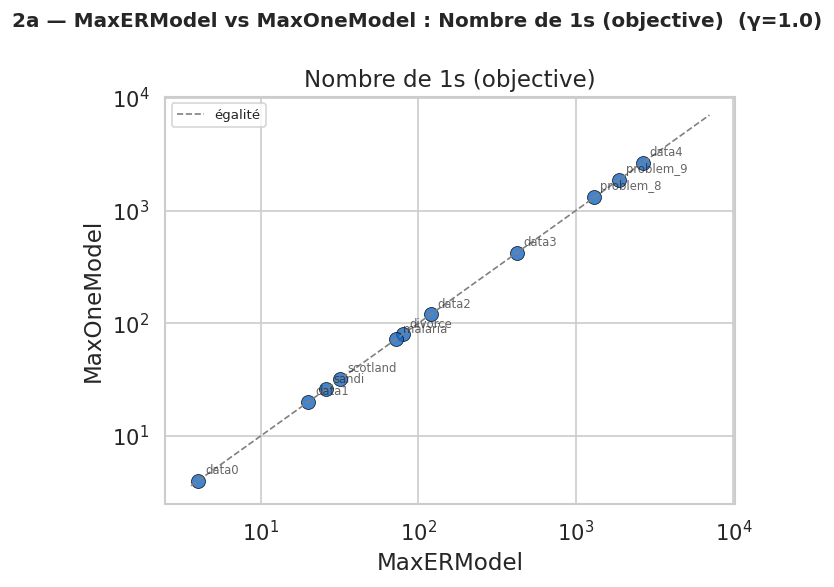

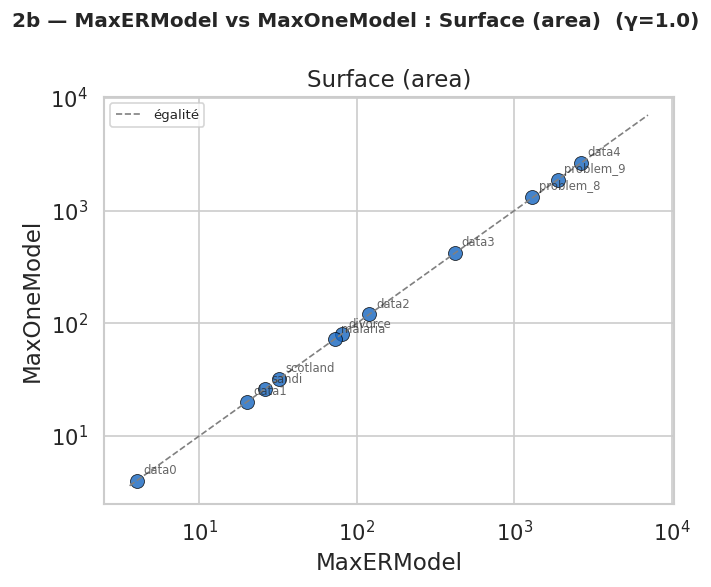

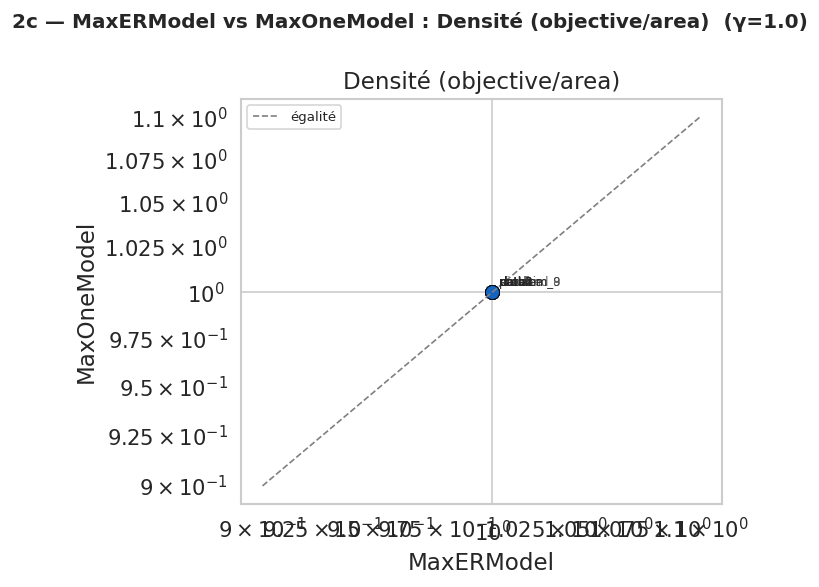

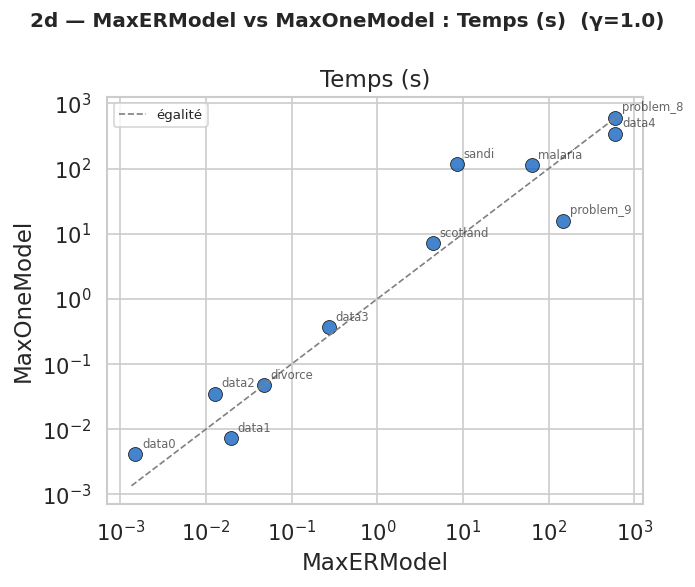

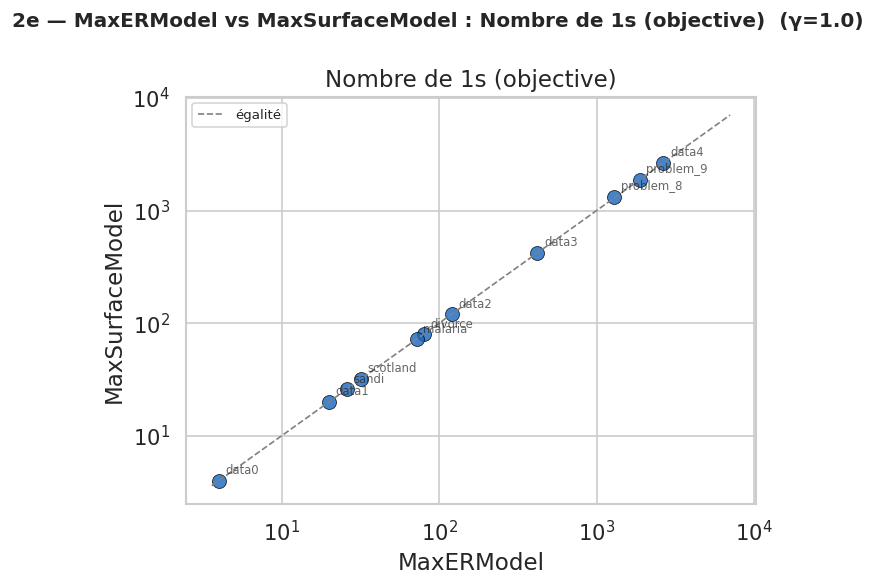

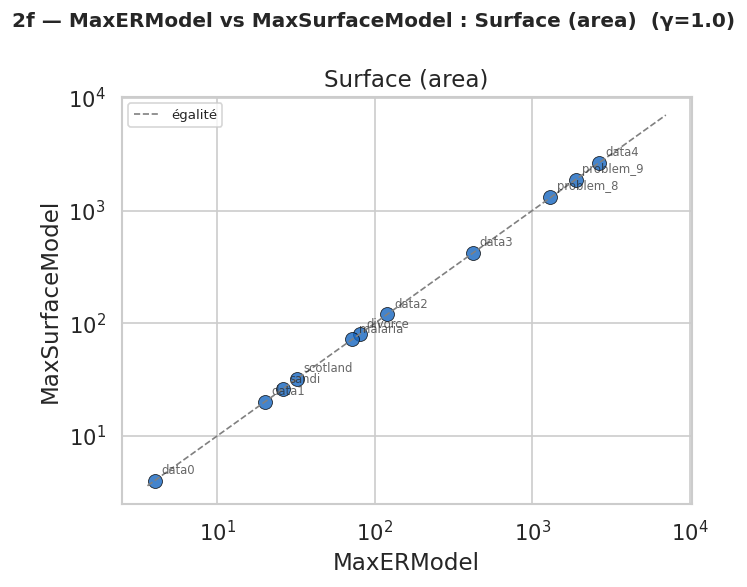

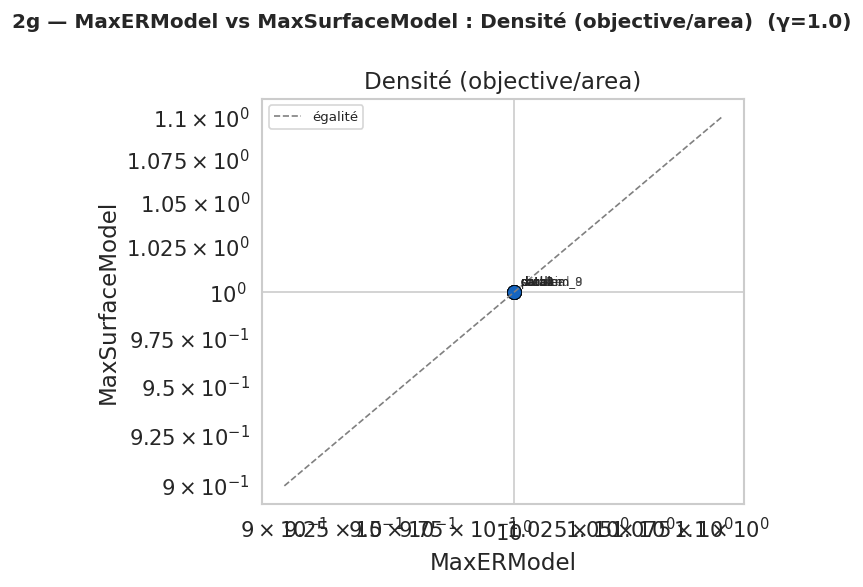

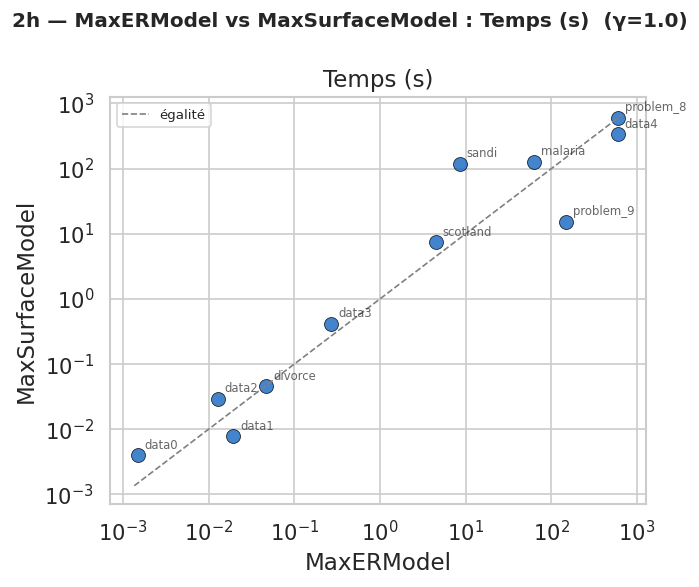

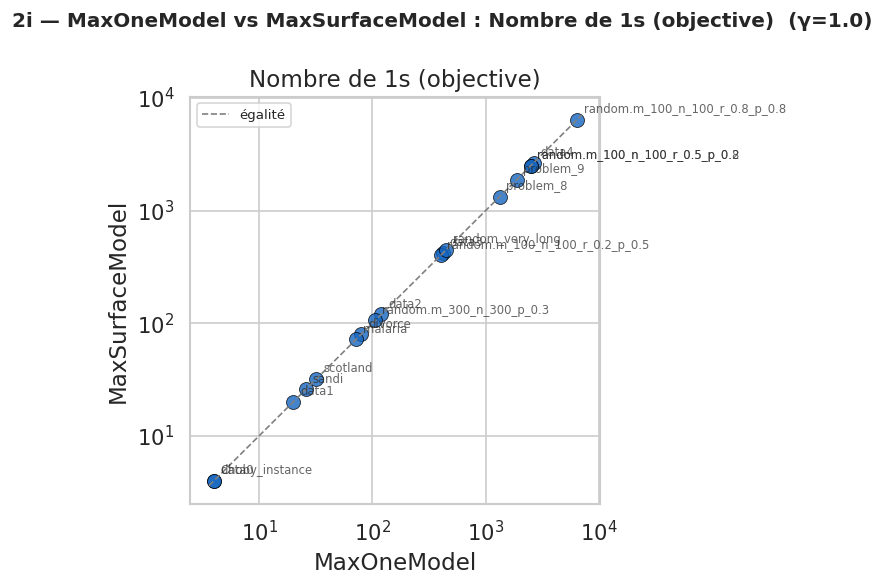

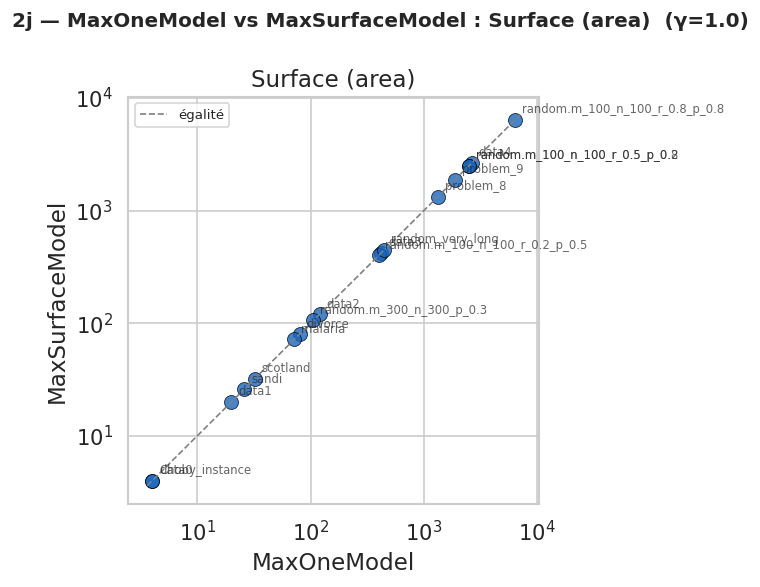

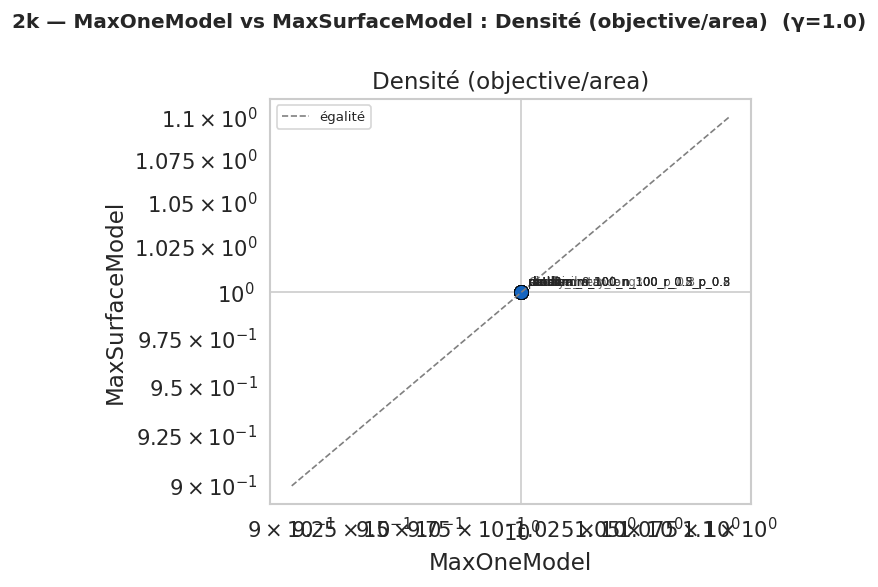

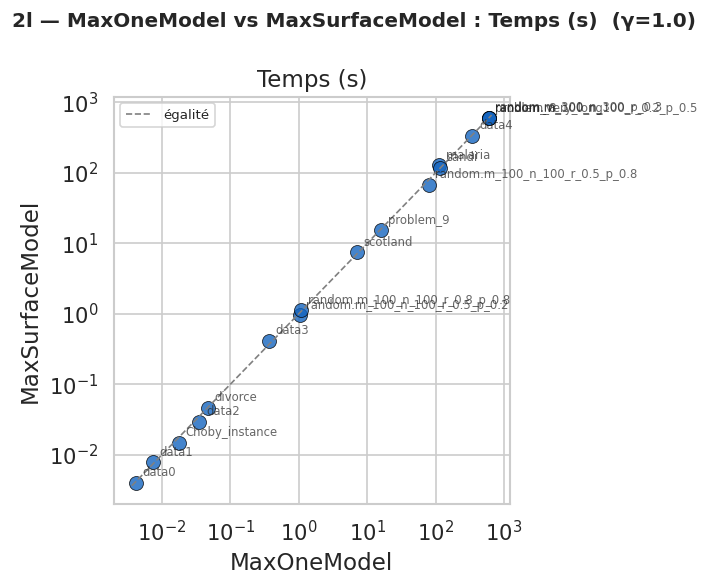

In [20]:
for gamma_val in gammas:
    df_g = df[df["gamma"] == gamma_val]
    _, _, _, df_solver_cmp_g = build_subsets(df_g)
    
    if df_solver_cmp_g is None or df_solver_cmp_g.empty:
        print(f"γ={gamma_val} — Moins de 2 solveurs exacts — section ignorée")
        continue
    
    solvers_list = sorted(df_g[~df_g["is_heuristic"]]["solver"].unique().tolist())
    if SOLVER_PAIRS is None or len(SOLVER_PAIRS) == 0:
        solver_pairs = list(combinations(solvers_list, 2))
    else:
        solver_pairs = SOLVER_PAIRS
    
    if not solver_pairs:
        continue
    
    metrics = [
        ("objective", "Nombre de 1s (objective)"),
        ("area",      "Surface (area)"),
        ("density",   "Densité (objective/area)"),
        ("time",      "Temps (s)"),
    ]
    
    pair_idx = 0
    for s0, s1 in solver_pairs:
        if s0 not in solvers_list or s1 not in solvers_list:
            continue
        pair_metrics = [(m, lbl) for m, lbl in metrics
                       if (m, s0) in df_solver_cmp_g.columns and (m, s1) in df_solver_cmp_g.columns]
        if not pair_metrics:
            continue
        for m_idx, (m, lbl) in enumerate(pair_metrics):
            fig, ax = plt.subplots(figsize=(6, 5))
            pair_letter = chr(ord("a") + pair_idx)
            fig.suptitle(f"2{pair_letter} — {s0} vs {s1} : {lbl}  (γ={gamma_val})",
                         fontsize=12, fontweight="bold")
            x = df_solver_cmp_g[(m, s0)]
            y = df_solver_cmp_g[(m, s1)]
            _sc = _scale.get(m, recommend_scale(pd.concat([x.dropna(), y.dropna()])))
            ax.scatter(x, y, s=70, alpha=0.8, edgecolors="k", linewidths=0.5,
                       color="#1565c0")
            ax.set_xscale(_sc)
            ax.set_yscale(_sc)
            for inst in df_solver_cmp_g.index:
                ax.annotate(inst,
                            (df_solver_cmp_g.loc[inst, (m, s0)],
                             df_solver_cmp_g.loc[inst, (m, s1)]),
                            fontsize=7, alpha=0.7, xytext=(4, 4),
                            textcoords="offset points")
            all_vals = pd.concat([x.dropna(), y.dropna()])
            if len(all_vals) > 0:
                lo = all_vals.min() * 0.9
                hi = all_vals.max() * 1.1
                ax.plot([lo, hi], [lo, hi], "--", color="gray",
                        linewidth=1, label="égalité")
            ax.set_xlabel(s0)
            ax.set_ylabel(s1)
            ax.set_title(lbl)
            ax.legend(fontsize=8)
            plt.tight_layout()
            _pdf_figs_gamma.setdefault(gamma_val, []).append(
                (fig, f"2{pair_letter} — {s0} vs {s1} : {lbl}"))
            plt.show()
            pair_idx += 1

---
## 3 — Qualité de l'heuristique

Pour chaque paire *(instance, solveur)*, on compare la solution heuristique
à l'optimal exact du même solveur :

- **gap** : écart relatif (%) — pré-calculé dans le CSV
- **ratio** : `obj_heuristique / obj_exact` — idéalement proche de 1

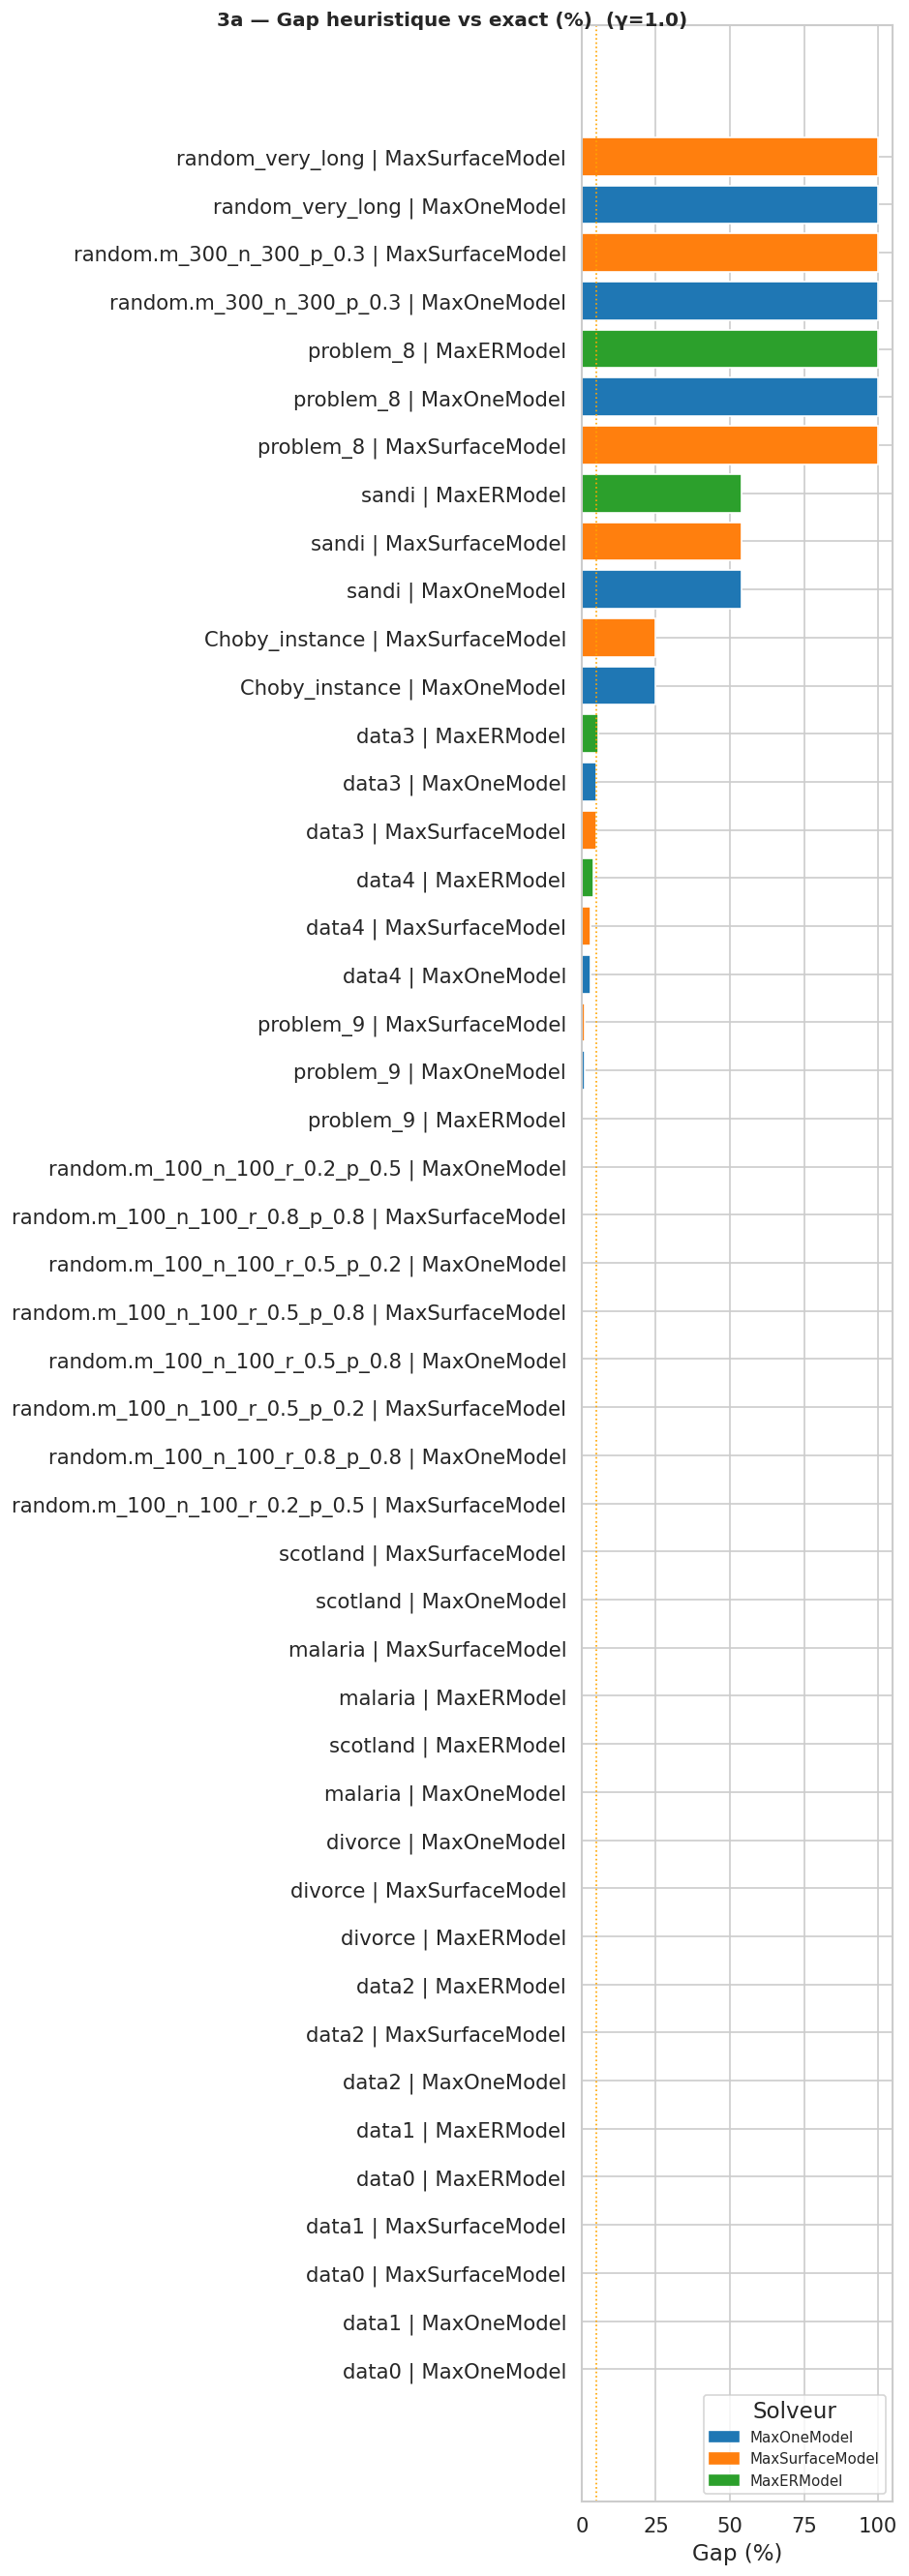

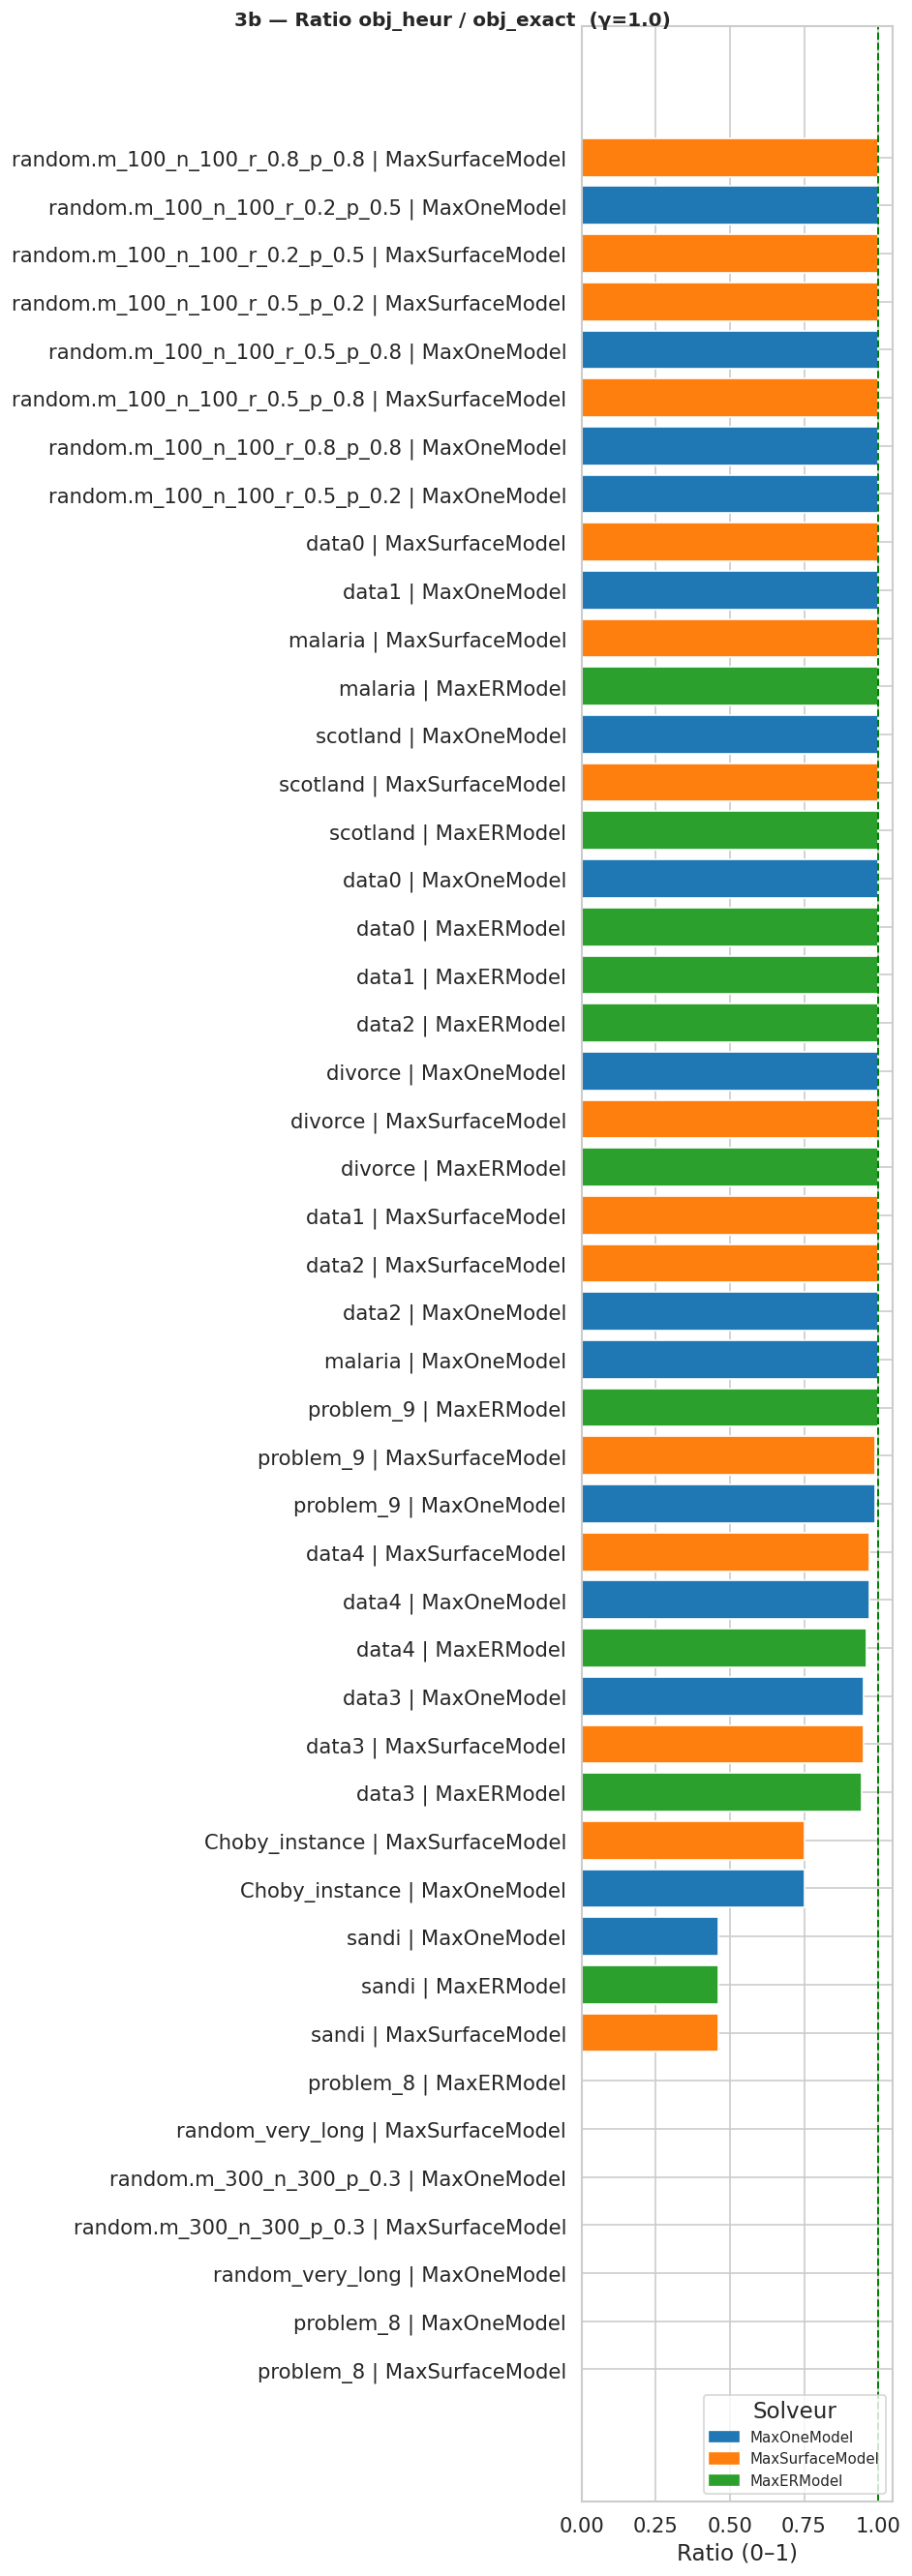

In [21]:
for gamma_val in gammas:
    df_g = df[df["gamma"] == gamma_val]
    _, _, df_paired_g, _ = build_subsets(df_g)
    
    if not len(df_paired_g):
        print(f"γ={gamma_val} — Aucune paire — section ignorée")
        continue
    
    n_rows = max(1, len(df_paired_g))
    solv_pal = dict(zip(
        df_paired_g["solver"].unique(),
        sns.color_palette("tab10", df_paired_g["solver"].nunique()),
    ))
    y_labels = df_paired_g.apply(lambda r: f"{r['instance_id']} | {r['solver']}", axis=1)
    colors   = [solv_pal.get(s, "gray") for s in df_paired_g["solver"]]
    handles  = [mpatches.Patch(color=c, label=s) for s, c in solv_pal.items()]

    if "gap" in df_paired_g.columns:
        order_idx = df_paired_g["gap"].fillna(0).argsort()
        fig3a, ax = plt.subplots(figsize=(8, max(4, n_rows * 0.45 + 1.5)))
        fig3a.suptitle(f"3a — Gap heuristique vs exact (%)  (γ={gamma_val})",
                       fontsize=12, fontweight="bold")
        ax.barh(y_labels.iloc[order_idx], df_paired_g["gap"].iloc[order_idx],
                color=[colors[i] for i in order_idx], edgecolor="white")
        ax.axvline(x=0, color="green", linewidth=1.2, linestyle="--", label="gap=0 (optimal)")
        ax.axvline(x=5, color="orange", linewidth=1, linestyle=":", label="5 %")
        ax.set_xlabel("Gap (%)")
        ax.legend(handles=handles, title="Solveur", loc="lower right", fontsize=9)
        plt.tight_layout()
        _pdf_figs_gamma.setdefault(gamma_val, []).append(
            (fig3a, "3a — Gap heuristique vs exact"))
        plt.show()

    if "obj_ratio" in df_paired_g.columns:
        valid      = df_paired_g.dropna(subset=["obj_ratio"])
        if len(valid):
            order_idx2 = valid["obj_ratio"].argsort()
            y2 = valid.apply(lambda r: f"{r['instance_id']} | {r['solver']}", axis=1)
            c2 = [solv_pal.get(s, "gray") for s in valid["solver"]]
            fig3b, ax = plt.subplots(figsize=(8, max(4, len(valid) * 0.45 + 1.5)))
            fig3b.suptitle(f"3b — Ratio obj_heur / obj_exact  (γ={gamma_val})",
                           fontsize=12, fontweight="bold")
            ax.barh(y2.iloc[order_idx2], valid["obj_ratio"].iloc[order_idx2],
                    color=[c2[i] for i in order_idx2], edgecolor="white")
            ax.axvline(x=1, color="green", linewidth=1.2, linestyle="--", label="ratio=1")
            ax.set_xlabel("Ratio (0–1)")
            ax.legend(handles=handles, title="Solveur", loc="lower right", fontsize=9)
            plt.tight_layout()
            _pdf_figs_gamma.setdefault(gamma_val, []).append(
                (fig3b, "3b — Ratio qualité heuristique"))
            plt.show()

---
## 4 — Compromis vitesse / qualité

Le graphique central de l'expérience : pour chaque paire *(instance, solveur)*,
on trace **speedup = temps_exact / temps_heuristique** en abscisse et **gap (%)** en
ordonnée.

- **Idéal** : speedup élevé + gap faible (coin bas-droit)
- **Mauvais** : speedup faible ET gap élevé (coin haut-gauche)

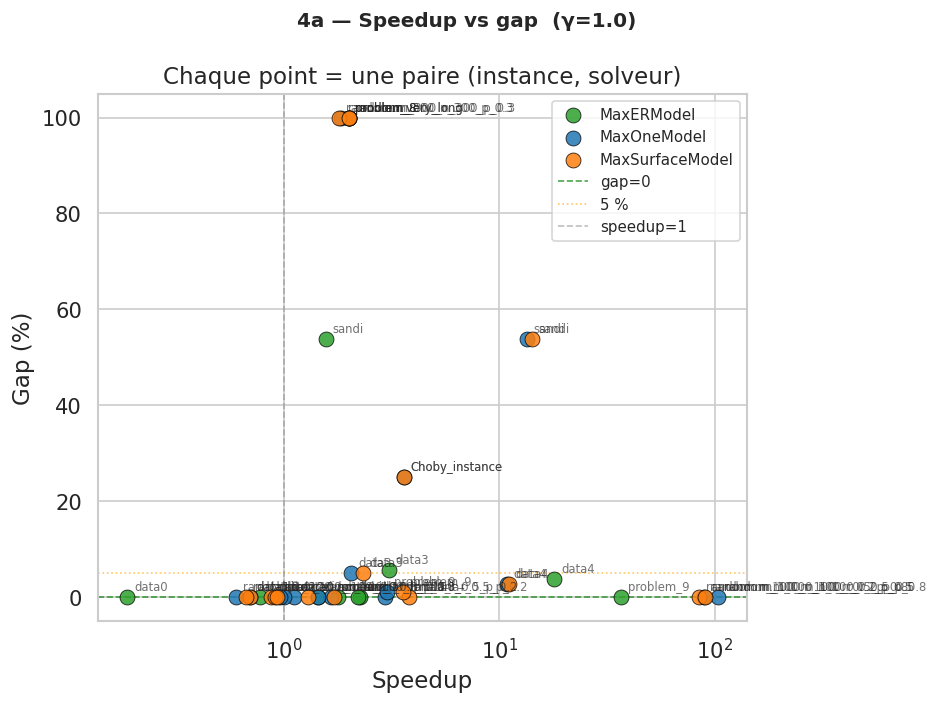

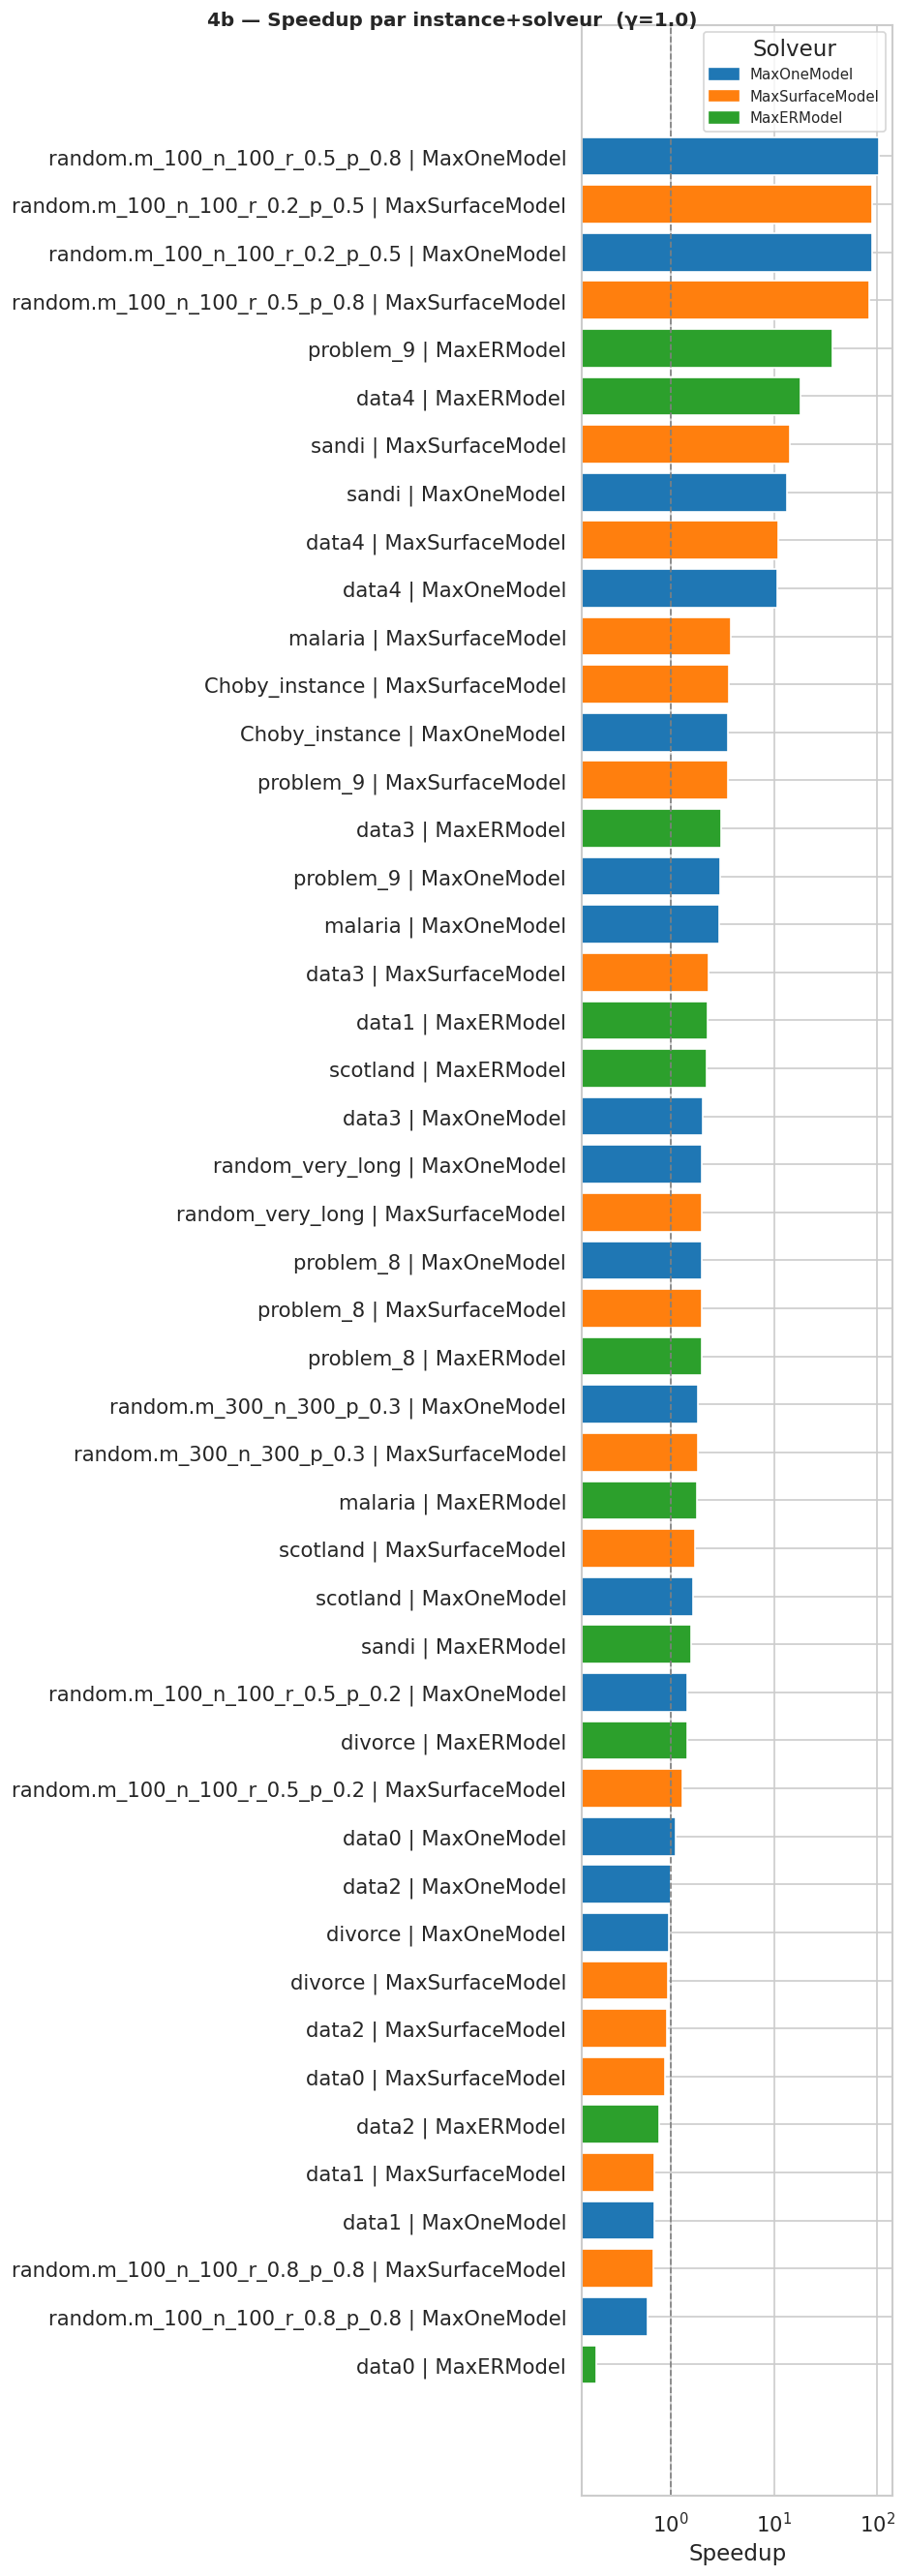

In [22]:
for gamma_val in gammas:
    df_g = df[df["gamma"] == gamma_val]
    _, _, df_paired_g, _ = build_subsets(df_g)
    
    if not len(df_paired_g):
        continue
    
    solv_pal = dict(zip(
        df_paired_g["solver"].unique(),
        sns.color_palette("tab10", df_paired_g["solver"].nunique()),
    ))

    # Fig 4a : Scatter speedup vs gap
    fig4a, ax = plt.subplots(figsize=(8, 6))
    fig4a.suptitle(f"4a — Speedup vs gap  (γ={gamma_val})",
                   fontsize=12, fontweight="bold")
    for solver, grp in df_paired_g.groupby("solver"):
        ax.scatter(grp["speedup"], grp["gap"],
                   label=solver, s=80, alpha=0.85,
                   color=solv_pal.get(solver, "gray"),
                   edgecolors="k", linewidths=0.5, zorder=3)
        for _, row in grp.iterrows():
            ax.annotate(row["instance_id"], (row["speedup"], row["gap"]),
                        fontsize=7, alpha=0.65,
                        xytext=(4, 4), textcoords="offset points")
    ax.axhline(y=0, color="green",  linestyle="--", linewidth=1, alpha=0.7, label="gap=0")
    ax.axhline(y=5, color="orange", linestyle=":",  linewidth=1, alpha=0.6, label="5 %")
    ax.axvline(x=1, color="gray",   linestyle="--", linewidth=1, alpha=0.5, label="speedup=1")
    ax.set_xscale(_scale.get("speedup", recommend_scale(df_paired_g["speedup"])))
    ax.set_xlabel("Speedup")
    ax.set_ylabel("Gap (%)")
    ax.set_title("Chaque point = une paire (instance, solveur)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    _pdf_figs_gamma.setdefault(gamma_val, []).append(
        (fig4a, "4a — Scatter speedup vs gap"))
    plt.show()

    # Fig 4b : Speedup par instance
    df_spd = df_paired_g.sort_values("speedup", ascending=True).reset_index(drop=True)
    y_lbl  = df_spd.apply(lambda r: f"{r['instance_id']} | {r['solver']}", axis=1)
    colors = [solv_pal.get(s, "gray") for s in df_spd["solver"]]
    fig4b, ax2 = plt.subplots(figsize=(8, max(4, len(df_spd) * 0.45 + 1.5)))
    fig4b.suptitle(f"4b — Speedup par instance+solveur  (γ={gamma_val})",
                   fontsize=12, fontweight="bold")
    ax2.barh(y_lbl, df_spd["speedup"], color=colors, edgecolor="white")
    ax2.axvline(x=1, color="gray", linestyle="--", linewidth=1)
    ax2.set_xscale(_scale.get("speedup", recommend_scale(df_paired_g["speedup"])))
    ax2.set_xlabel("Speedup")
    handles = [mpatches.Patch(color=c, label=s) for s, c in solv_pal.items()]
    ax2.legend(handles=handles, title="Solveur", fontsize=9)
    plt.tight_layout()
    _pdf_figs_gamma.setdefault(gamma_val, []).append(
        (fig4b, "4b — Speedup par instance"))
    plt.show()

---
## 5 — Temps de résolution

Comparaison directe des temps exact vs heuristique par instance.
L'échelle log permet de visualiser des ordres de grandeur très différents.

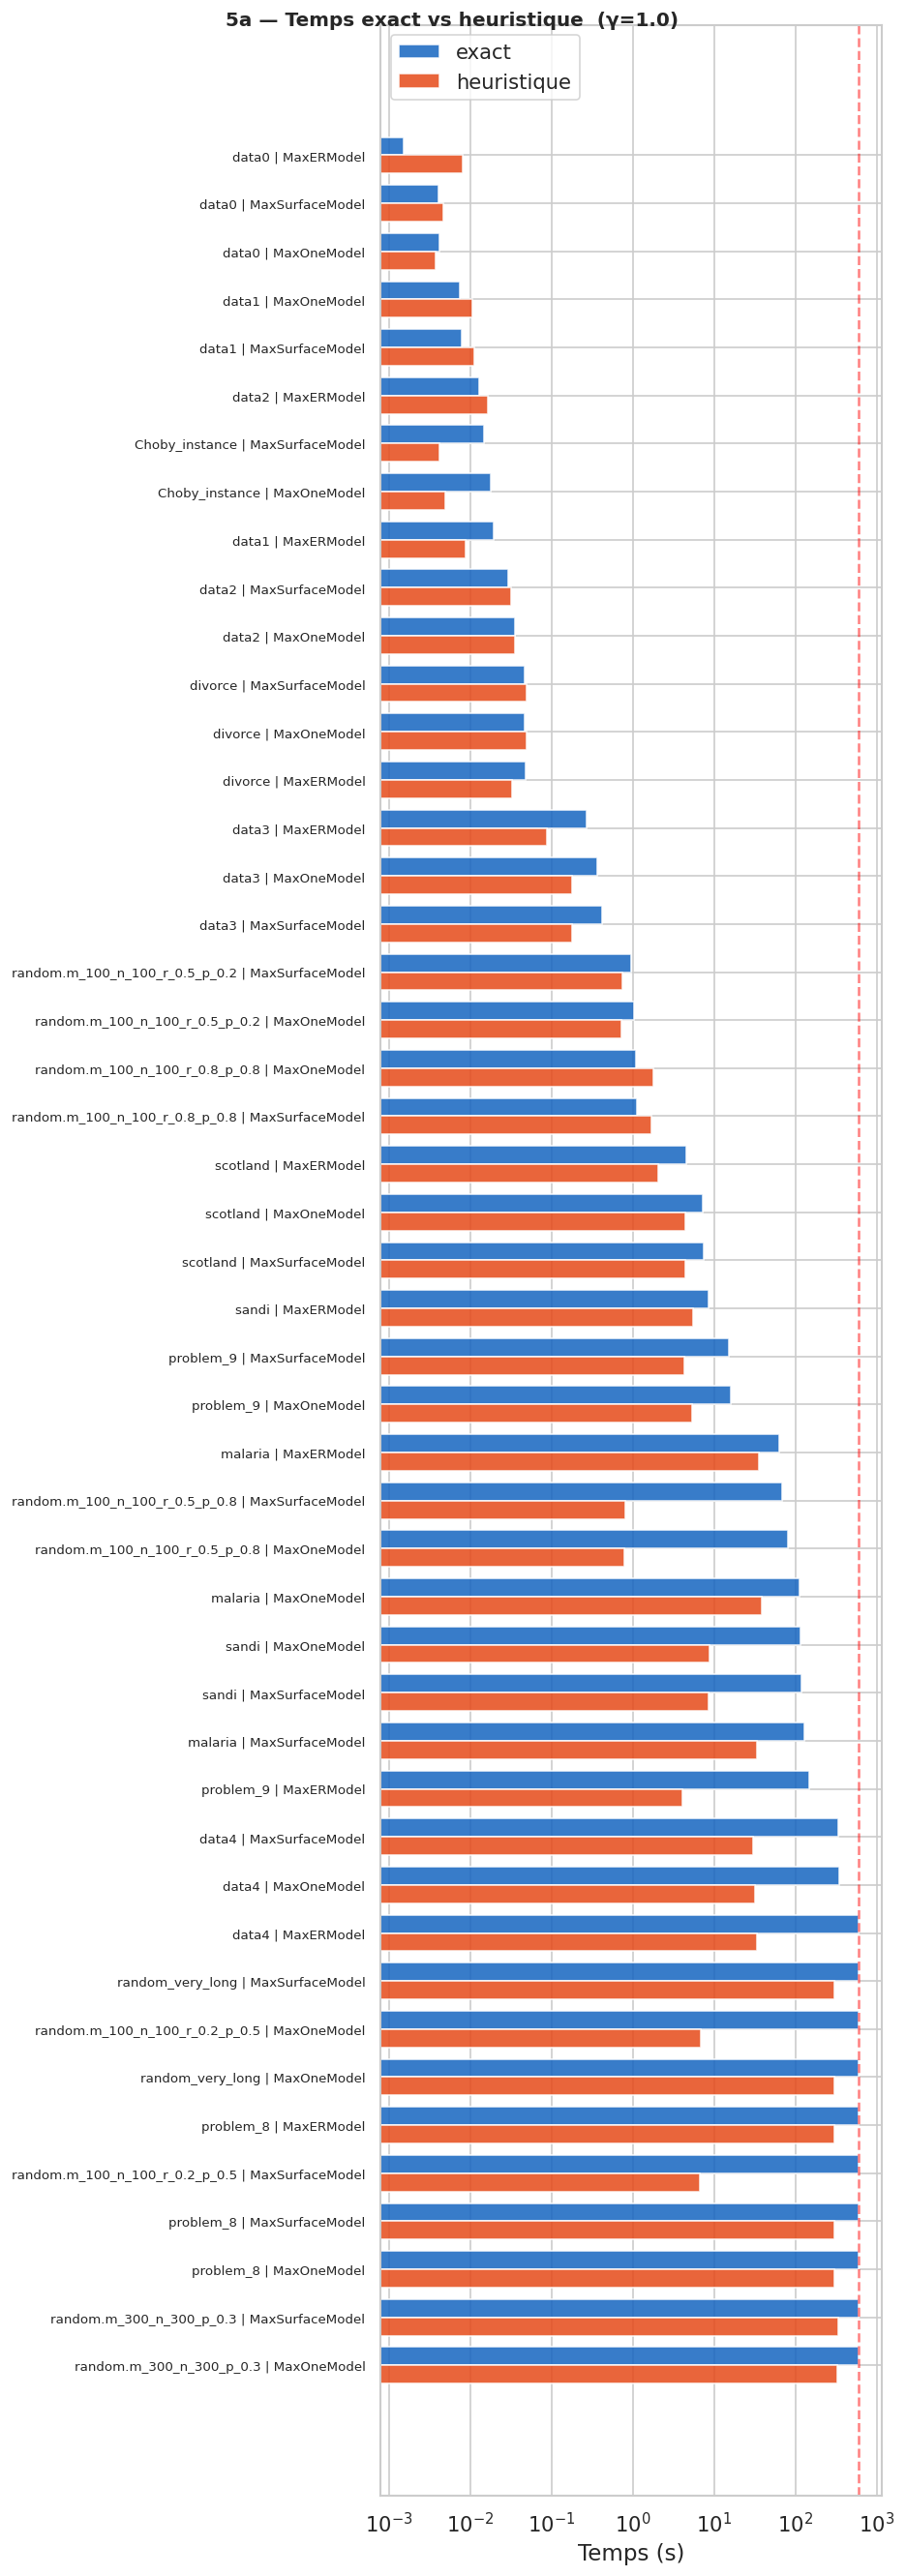

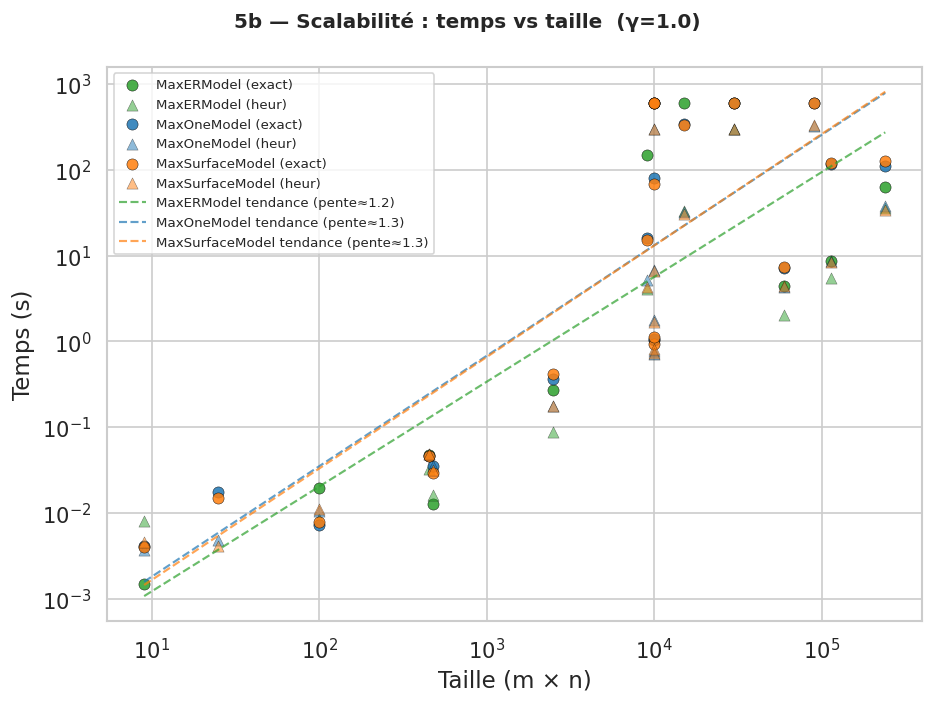

In [23]:
for gamma_val in gammas:
    df_g = df[df["gamma"] == gamma_val]
    df_exact_g, _, df_paired_g, _ = build_subsets(df_g)
    
    solv_pal = dict(zip(
        df_g["solver"].unique(),
        sns.color_palette("tab10", df_g["solver"].nunique()),
    ))

    # Fig 5a : Barres côte-à-côte
    fig5a, ax = plt.subplots(figsize=(8, max(4, len(df_paired_g) * 0.45 + 1.5)))
    fig5a.suptitle(f"5a — Temps exact vs heuristique  (γ={gamma_val})",
                   fontsize=12, fontweight="bold")
    if len(df_paired_g) > 0:
        df_t = df_paired_g.copy()
        df_t["label"] = df_t.apply(lambda r: f"{r['instance_id']} | {r['solver']}", axis=1)
        df_t = df_t.sort_values("time_exact", ascending=False).reset_index(drop=True)
        x     = np.arange(len(df_t))
        width = 0.38
        ax.barh(x + width/2, df_t["time_exact"], width,
                label="exact", color="#1565c0", alpha=0.85)
        ax.barh(x - width/2, df_t["time_heur"],  width,
                label="heuristique", color="#e64a19", alpha=0.85)
        ax.set_yticks(x)
        ax.set_yticklabels(df_t["label"], fontsize=8)
        ax.set_xscale(_scale.get("time", recommend_scale(df_g["time"])))
        ax.set_xlabel("Temps (s)")
        ax.legend()
        ax.axvline(x=600, color="red", linestyle="--", alpha=0.5, label="timeout 600s")
    else:
        ax.text(0.5, 0.5, "Aucune paire disponible",
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
    plt.tight_layout()
    _pdf_figs_gamma.setdefault(gamma_val, []).append(
        (fig5a, "5a — Temps exact vs heuristique"))
    plt.show()

    # Fig 5b : Scalabilité
    fig5b, ax2 = plt.subplots(figsize=(8, 6))
    fig5b.suptitle(f"5b — Scalabilité : temps vs taille  (γ={gamma_val})",
                   fontsize=12, fontweight="bold")
    for (solver, is_h), grp in df_g.groupby(["solver", "is_heuristic"]):
        marker = "^" if is_h else "o"
        label  = f"{solver} ({'heur' if is_h else 'exact'})"
        color  = solv_pal.get(solver, "gray")
        alpha  = 0.5 if is_h else 0.85
        ax2.scatter(grp["size"], grp["time"],
                    marker=marker, label=label, alpha=alpha,
                    s=45, color=color, edgecolors="k", linewidths=0.3)
    _sx = _scale.get("size", recommend_scale(df_g["size"]))
    _st = _scale.get("time", recommend_scale(df_g["time"]))
    if _sx == "log" and _st == "log":
        for solver, grp in df_exact_g.groupby("solver"):
            v = grp[["size", "time"]].dropna()
            if len(v) >= 3:
                lx   = np.log10(v["size"].values)
                ly   = np.log10(v["time"].clip(lower=1e-9).values)
                coef = np.polyfit(lx, ly, 1)
                xs   = np.linspace(lx.min(), lx.max(), 50)
                ax2.plot(10**xs, 10**np.polyval(coef, xs),
                         linestyle="--", linewidth=1.3,
                         color=solv_pal.get(solver, "gray"), alpha=0.7,
                         label=f"{solver} tendance (pente≈{coef[0]:.1f})")
    ax2.set_xscale(_sx)
    ax2.set_yscale(_st)
    ax2.set_xlabel("Taille (m × n)")
    ax2.set_ylabel("Temps (s)")
    ax2.legend(fontsize=8, ncol=1)
    plt.tight_layout()
    _pdf_figs_gamma.setdefault(gamma_val, []).append(
        (fig5b, "5b — Scalabilité"))
    plt.show()

---
## 6 — Heatmap fiabilité : instance × solveur

Vue synthétique 2D du gap par *(instance, solveur)*.
Permet d'identifier d'un coup d'œil :
- les instances difficiles pour l'heuristique (ligne rouge)
- les solveurs où l'heuristique est systématiquement meilleure / pire (colonne)

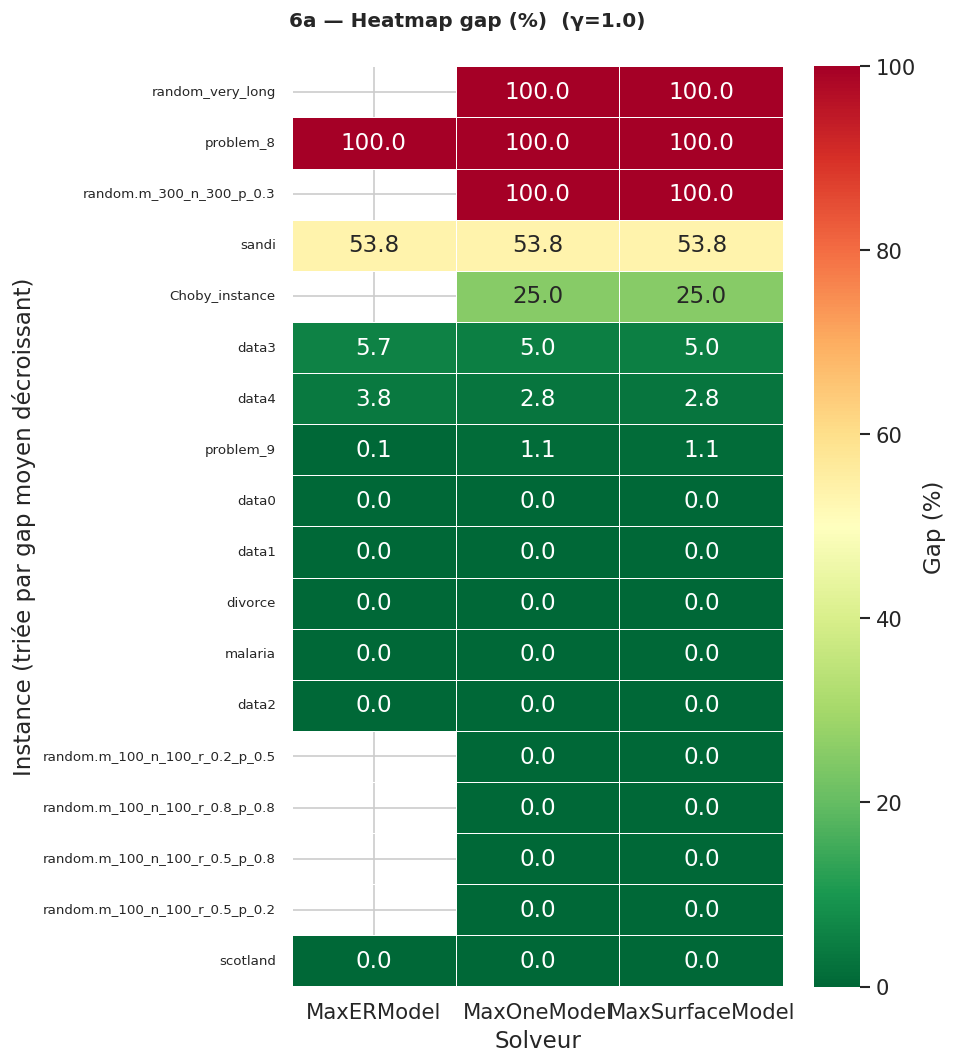

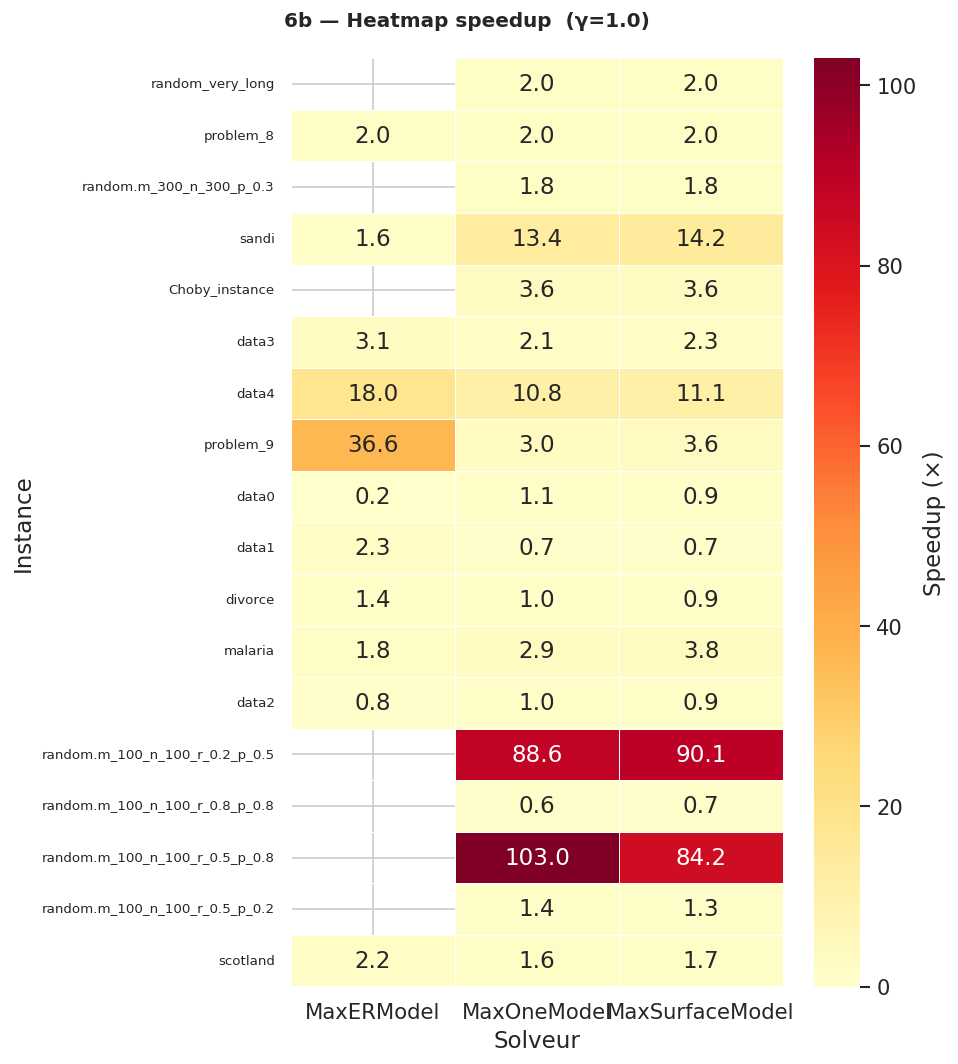

In [24]:
for gamma_val in gammas:
    df_g = df[df["gamma"] == gamma_val]
    _, _, df_paired_g, _ = build_subsets(df_g)
    
    if not len(df_paired_g) or "gap" not in df_paired_g.columns:
        continue
    
    gap_pivot = df_paired_g.pivot_table(
        index="instance_id", columns="solver", values="gap", aggfunc="mean")
    gap_pivot = gap_pivot.loc[gap_pivot.mean(axis=1).sort_values(ascending=False).index]
    n_inst_h  = gap_pivot.shape[0]

    fig6a, ax = plt.subplots(figsize=(8, max(4, n_inst_h * 0.42 + 1.5)))
    fig6a.suptitle(f"6a — Heatmap gap (%)  (γ={gamma_val})",
                   fontsize=12, fontweight="bold")
    sns.heatmap(gap_pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
                vmin=0, linewidths=0.5, ax=ax,
                cbar_kws={"label": "Gap (%)"})
    ax.set_xlabel("Solveur")
    ax.set_ylabel("Instance (triée par gap moyen décroissant)")
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    _pdf_figs_gamma.setdefault(gamma_val, []).append(
        (fig6a, "6a — Heatmap gap"))
    plt.show()

    spd_pivot = df_paired_g.pivot_table(
        index="instance_id", columns="solver", values="speedup", aggfunc="mean")
    spd_pivot = spd_pivot.loc[gap_pivot.index.intersection(spd_pivot.index)]
    fig6b, ax2 = plt.subplots(figsize=(8, max(4, spd_pivot.shape[0] * 0.42 + 1.5)))
    fig6b.suptitle(f"6b — Heatmap speedup  (γ={gamma_val})",
                   fontsize=12, fontweight="bold")
    sns.heatmap(spd_pivot, annot=True, fmt=".1f", cmap="YlOrRd",
                vmin=0, linewidths=0.5, ax=ax2,
                cbar_kws={"label": "Speedup (×)"})
    ax2.set_xlabel("Solveur")
    ax2.set_ylabel("Instance")
    ax2.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    _pdf_figs_gamma.setdefault(gamma_val, []).append(
        (fig6b, "6b — Heatmap speedup"))
    plt.show()

---
## 7 — Overlay solution (JSON log + matrice binaire)

Visualise la solution retournée pour un run spécifique issu d'un log JSON :
- à gauche : la matrice complète avec les lignes/colonnes sélectionnées en rouge
- à droite : la sous-matrice sélectionnée agrandie

**Activation** : renseigner `JSON_LOG_PATH` et `MATRIX_DIR` dans la cellule de
configuration.

In [25]:
def _find_load_fn():
    """Cherche utils/matrix_io dans les répertoires parents."""
    try:
        from utils.matrix_io import load_csv_matrix
        return load_csv_matrix
    except ImportError:
        pass
    for parent in [Path().resolve()] + list(Path().resolve().parents):
        if (parent / "utils" / "matrix_io.py").exists():
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            try:
                from utils.matrix_io import load_csv_matrix
                return load_csv_matrix
            except ImportError:
                break
    return None


def load_matrix(matrix_dir: Path, instance_id: str) -> np.ndarray:
    """Charge la matrice binaire CSV d'une instance."""
    path = matrix_dir / f"{instance_id}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Matrice introuvable : {path}")
    fn = _find_load_fn()
    if fn is not None:
        return np.asarray(fn(str(path)), dtype=int)
    return pd.read_csv(path, header=None).values.astype(int)


def visualize_solution(json_path: Path, matrix_dir: Path) -> plt.Figure:
    """Affiche la matrice avec la solution en overlay."""
    with open(json_path) as f:
        log = json.load(f)

    instance_id = log.get("instance_id")
    sel_rows    = [int(r) for r in log.get("selected_rows", [])]
    sel_cols    = [int(c) for c in log.get("selected_cols", [])]
    solver      = log.get("solver_used") or log.get("solver", "?")
    heuristic   = log.get("heuristic", "exact")
    csv_row     = log.get("csv_row", {})
    obj_val     = csv_row.get("objective", "?")
    gap_val     = csv_row.get("gap", "?")

    mat          = load_matrix(matrix_dir, instance_id)
    nrows, ncols = mat.shape

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"7 — Overlay : {instance_id}  |  solveur={solver}  heuristique={heuristic}\n"
        f"obj={obj_val}  gap={gap_val}%  "
        f"sélection : {len(sel_rows)} lignes × {len(sel_cols)} colonnes",
        fontsize=11, fontweight="bold",
    )

    sns.heatmap(mat.astype(float), cmap="Greys", cbar=True, ax=axes[0],
                linewidths=0, xticklabels=False, yticklabels=False)
    for r in sel_rows:
        for c in sel_cols:
            if 0 <= r < nrows and 0 <= c < ncols:
                axes[0].add_patch(mpatches.Rectangle(
                    (c, r), 1, 1, fill=True,
                    facecolor="#ff4444", alpha=0.35,
                    edgecolor="red", linewidth=0.8,
                ))
    axes[0].set_title(f"Matrice complète {nrows}×{ncols}")

    r_v = [r for r in sel_rows if 0 <= r < nrows]
    c_v = [c for c in sel_cols if 0 <= c < ncols]
    if r_v and c_v:
        sub = mat[np.ix_(r_v, c_v)]
        sns.heatmap(sub, cmap="RdYlGn", vmin=0, vmax=1, cbar=True,
                    annot=(sub.size <= 200), fmt="d",
                    linewidths=0.5, linecolor="#cccccc", ax=axes[1])
        axes[1].set_title(
            f"Sous-matrice ({len(r_v)}×{len(c_v)})  densité={sub.mean():.3f}")
    else:
        axes[1].text(0.5, 0.5, "Sélection vide", ha="center", va="center",
                     transform=axes[1].transAxes)
        axes[1].axis("off")

    plt.tight_layout()
    return fig


# ── Exécution ─────────────────────────────────────────────────────────────────
if JSON_LOG_PATH is None or MATRIX_DIR is None:
    print("Overlay désactivé. Renseignez JSON_LOG_PATH et MATRIX_DIR dans la config.")
else:
    try:
        fig_ov = visualize_solution(Path(JSON_LOG_PATH), Path(MATRIX_DIR))
        _pdf_figs.append((fig_ov, "7 — Overlay solution"))
        plt.show()
    except FileNotFoundError as e:
        print(f"Fichier introuvable : {e}")
    except Exception as e:
        print(f"Erreur overlay : {e}")

Overlay désactivé. Renseignez JSON_LOG_PATH et MATRIX_DIR dans la config.


---
## 8 — Export PDF

Génère un rapport complet avec :
- page de couverture + métadonnées
- chaque figure
- une page d'analyse textuelle automatique par section

In [26]:
def _cover_page(df: pd.DataFrame, csv_source) -> plt.Figure:
    """Page de couverture."""
    fig = plt.figure(figsize=(11.7, 8.3))
    fig.patch.set_facecolor("white")
    ax  = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

    ax.add_patch(mpatches.Rectangle((0, 0.82), 1, 0.18,
                 color="#1565c0", transform=ax.transAxes, zorder=0))
    ax.text(0.5, 0.91, "Analyse des résultats — Pipeline T1",
            ha="center", va="center", fontsize=22,
            fontweight="bold", color="white", transform=ax.transAxes)

    src_str = str(csv_source) if not isinstance(csv_source, list) else f"{len(csv_source)} fichier(s)"
    items = [
        f"Date de génération : {datetime.now():%Y-%m-%d %H:%M}",
        f"Source CSV         : {src_str}",
        f"Lignes totales     : {len(df)}",
    ]
    if "instance_id" in df.columns:
        items.append(f"Instances          : {df['instance_id'].nunique()}")
    if "solver" in df.columns:
        items.append(f"Solveurs           : {', '.join(df['solver'].unique())}")
    if "status" in df.columns:
        items.append(f"Statuts            : {df['status'].value_counts().to_dict()}")
    if "gamma" in df.columns:
        items.append(f"Valeurs de gamma   : {sorted(df['gamma'].dropna().unique().tolist())}")
    items.append(f"Runs exacts        : {len(df_exact)}")
    items.append(f"Runs heuristiques  : {len(df_heur)}")

    y = 0.70
    for line in items:
        ax.text(0.08, y, line, ha="left", va="center", fontsize=11,
                transform=ax.transAxes, family="monospace")
        y -= 0.060

    ax.text(0.5, 0.03, "Généré avec matplotlib · Pipeline T1 · Experiment-M2",
            ha="center", va="center", fontsize=9, color="#888888",
            transform=ax.transAxes)
    return fig


def _gamma_title_page(gamma_val) -> plt.Figure:
    """Page titre pour un groupe gamma."""
    fig = plt.figure(figsize=(11.7, 8.3))
    fig.patch.set_facecolor("white")
    ax  = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(mpatches.Rectangle((0, 0.40), 1, 0.20,
                 color="#1565c0", transform=ax.transAxes, zorder=0))
    ax.text(0.5, 0.50, f"γ = {gamma_val}",
            ha="center", va="center", fontsize=44,
            fontweight="bold", color="white", transform=ax.transAxes)
    ax.text(0.5, 0.32, "Contrainte de densité minimale",
            ha="center", va="center", fontsize=14,
            color="#666666", transform=ax.transAxes)
    return fig


# ── Export ────────────────────────────────────────────────────────────────────────────
pdf_path = Path(PDF_OUTPUT)
pdf_path.parent.mkdir(parents=True, exist_ok=True)

with PdfPages(pdf_path) as pdf:
    # Couverture
    fig_cov = _cover_page(df, CSV_SOURCE)
    pdf.savefig(fig_cov, bbox_inches="tight")
    plt.close(fig_cov)

    # Figures globales (S1, overlay, etc.)
    for fig, title in _pdf_figs:
        pdf.savefig(fig, bbox_inches="tight")

    # Figures par gamma
    for gamma_val in gammas:
        fig_gt = _gamma_title_page(gamma_val)
        pdf.savefig(fig_gt, bbox_inches="tight")
        plt.close(fig_gt)
        for fig, title in _pdf_figs_gamma.get(gamma_val, []):
            pdf.savefig(fig, bbox_inches="tight")

    d = pdf.infodict()
    d["Title"]        = "Analyse des résultats — Pipeline T1"
    d["Author"]       = "Pipeline T1 / Experiment-M2"
    d["Subject"]      = "Comparaison solveurs exacts vs heuristique"
    d["CreationDate"] = datetime.now()

n_gamma_figs = sum(len(v) for v in _pdf_figs_gamma.values())
print(f"PDF généré  : {pdf_path.resolve()}")
print(f"Taille      : {pdf_path.stat().st_size / 1024:.0f} Ko")
print(f"Figures globales    : {len(_pdf_figs)}")
print(f"Figures par gamma   : {n_gamma_figs} ({len(_pdf_figs_gamma)} groupes)")

PDF généré  : /udd/mfoin/exper/experiment-M2/graphique/rapport_analyse.pdf
Taille      : 125 Ko
Figures globales    : 2
Figures par gamma   : 20 (1 groupes)
